# Predicting Game Recommendations with Interpretable AI

**Course:** Advanced Customer Analytics  
**Institution:** Athens University of Economics and Business (AUEB)  
**Student:** Michail Theophanopoulos  

---

## Overview
This project demonstrates interpretable machine learning by predicting Steam game recommendations and generating actionable counterfactual explanations for developers.

---

In [ ]:
# Install required packages (uncomment to run)

# !pip install pandas
# !pip install numpy
# !pip install scikit-learn
# !pip install xgboost
# !pip install matplotlib
# !pip install seaborn
# !pip install textblob
# !pip install requests

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
from pathlib import Path
import time
import logging
from typing import List, Dict, Optional

# Data collection
import requests

# ML libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    accuracy_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# XGBoost
from xgboost import XGBClassifier

# Text processing
from textblob import TextBlob

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Cross-validation
from sklearn.model_selection import cross_val_score, StratifiedKFold

from sklearn.metrics import ConfusionMatrixDisplay, classification_report, RocCurveDisplay, PrecisionRecallDisplay

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Predicting Game Recommendations with Interpretable AI

We start by collecting real player reviews from Steam to understand what drives recommendations.

In [ ]:
def scrape_steam_reviews(app_id: int, max_reviews: int = 50000, language: str = 'english', reviews_per_page: int = 100) -> List[Dict]:
    """
    Scrape game reviews from Steam API for a specific game.
    
    Fetches review data from Steam's public API with pagination support,
    including review content, user information, and engagement metrics.
    """
    all_reviews = []
    cursor = '*'
    
    while len(all_reviews) < max_reviews:
        url = f'https://store.steampowered.com/appreviews/{app_id}'
        params = {
            'json': 1,
            'language': language,
            'cursor': cursor,
            'num_per_page': reviews_per_page,
            'filter': 'recent'
        }
        
        try:
            response = requests.get(url, params=params, timeout=30)
            response.raise_for_status()
            data = response.json()
            
            if not data.get('reviews'):
                break
            
            all_reviews.extend(data['reviews'])
            cursor = data.get('cursor')
            
            if not cursor:
                break
            
            time.sleep(1)
            
        except requests.exceptions.RequestException as e:
            time.sleep(10)
            continue
    
    return all_reviews[:max_reviews]

In [ ]:
def fetch_game_details(app_id: int) -> Dict:
    """
    Fetch game metadata from Steam API.
    
    Retrieves detailed game information including title, price, genres,
    categories, developers, publishers, and description.
    """
    url = f'https://store.steampowered.com/api/appdetails'
    params = {'appids': app_id}
    
    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()
        
        if str(app_id) in data and data[str(app_id)]['success']:
            return data[str(app_id)]['data']
        else:
            return {}
            
    except requests.exceptions.RequestException:
        return {}


def process_reviews(reviews: List[Dict], game_data: Dict = None) -> pd.DataFrame:
    """
    Process raw review data into structured features.
    
    Extracts and transforms review metadata, user information, and game
    attributes into a pandas DataFrame ready for analysis.
    """
    data = []
    
    for review in reviews:
        author = review.get('author', {})
        
        record = {
            # Review features
            'recommended': review.get('voted_up', False),
            'review_text': review.get('review', ''),
            'review_length': len(review.get('review', '')),
            'playtime_at_review_hours': author.get('playtime_at_review', 0) / 60,
            'playtime_total_hours': author.get('playtime_forever', 0) / 60,
            'received_free': review.get('received_for_free', False),
            'written_early_access': review.get('written_during_early_access', False),
            
            # User features
            'user_id': author.get('steamid', ''),
            'user_games_owned': author.get('num_games_owned', 0),
            'user_num_reviews': author.get('num_reviews', 0),
            
            # Review metadata
            'votes_helpful': review.get('votes_up', 0),
            'votes_funny': review.get('votes_funny', 0),
            'weighted_vote_score': review.get('weighted_vote_score', 0.5),
            'comment_count': review.get('comment_count', 0),
            'timestamp_created': review.get('timestamp_created', 0),
            'timestamp_updated': review.get('timestamp_updated', 0),
            'review_id': review.get('recommendationid', 0),
        }
        
        # Game features
        if game_data:
            record.update({
                'game_id': game_data.get('steam_appid', 0),
                'game_name': game_data.get('name', ''),
                'game_price': game_data.get('price_overview', {}).get('final', 0) / 100 if game_data.get('price_overview') else 0,
                'game_required_age': game_data.get('required_age', 0),
                'game_genre': ','.join([g['description'] for g in game_data.get('genres', [])]),
                'game_categories': ','.join([c['description'] for c in game_data.get('categories', [])]),
                'game_developer': ','.join(game_data.get('developers', [])),
                'game_publisher': ','.join(game_data.get('publishers', [])),
                'game_description': game_data.get('short_description', ''),
                'game_is_free': game_data.get('is_free', False),
            })
        
        data.append(record)
    
    return pd.DataFrame(data)

In [395]:
# Scrape reviews from multiple games
GAMES = [236430, 1517290, 1938090, 1203220, 2357570, 976730, 1551360, 1294810, 954850, 1086940]
REVIEWS_PER_GAME = 2500
OUTPUT_FILE = 'steam_reviews_multi.csv'

all_game_dfs = []
total_games = len(GAMES)

print(f"Scraping {total_games} games ({REVIEWS_PER_GAME} reviews each)\n")

for idx, app_id in enumerate(GAMES, 1):
    try:
        print(f"[{idx}/{total_games}] Fetching {app_id}...", end=" ")
        game_data = fetch_game_details(app_id)
        
        if game_data:
            print(f"{game_data.get('name', 'Unknown')}", end=" ")
        
        time.sleep(2)
        
        reviews = scrape_steam_reviews(app_id=app_id, max_reviews=REVIEWS_PER_GAME)
        
        if len(reviews) > 0:
            df_game = process_reviews(reviews, game_data=game_data)
            all_game_dfs.append(df_game)
            print(f"✓ {len(reviews)} reviews")
        else:
            print("✗ No reviews")
        
        time.sleep(5)
        
    except Exception as e:
        print(f"✗ Error: {str(e)}")
        continue

if all_game_dfs:
    df = pd.concat(all_game_dfs, ignore_index=True)
    df.to_csv(OUTPUT_FILE, index=False)
    print(f"\nSaved {len(df)} total reviews to {OUTPUT_FILE}")

Scraping 10 games (2500 reviews each)

[1/10] Fetching 236430... DARK SOULS™ II ✓ 2500 reviews
[2/10] Fetching 1517290... Battlefield™ 2042 ✓ 2500 reviews
[3/10] Fetching 1938090... Call of Duty® ✓ 2500 reviews
[4/10] Fetching 1203220... NARAKA: BLADEPOINT ✓ 2500 reviews
[5/10] Fetching 2357570... Overwatch® 2 ✓ 126 reviews
[6/10] Fetching 976730... Halo: The Master Chief Collection ✓ 2500 reviews
[7/10] Fetching 1551360... Forza Horizon 5 ✓ 2500 reviews
[8/10] Fetching 1294810... Redfall ✓ 1629 reviews
[9/10] Fetching 954850... Kerbal Space Program 2 ✓ 2500 reviews
[10/10] Fetching 1086940... Baldur's Gate 3 ✓ 2500 reviews

Saved 21755 total reviews to steam_reviews_multi.csv


In [396]:
print(f"Dataset: {df.shape[0]} reviews, {df['game_id'].nunique()} games")
print(f"Positive: {df['recommended'].mean()*100:.1f}%\n")

for game_id in df['game_id'].unique():
    game_df = df[df['game_id'] == game_id]
    print(f"{game_df['game_name'].iloc[0]}: {len(game_df)} reviews ({game_df['recommended'].mean() * 100:.1f}% positive)")

Dataset: 21755 reviews, 10 games
Positive: 64.2%

DARK SOULS™ II: 2500 reviews (82.8% positive)
Battlefield™ 2042: 2500 reviews (47.8% positive)
Call of Duty®: 2500 reviews (43.8% positive)
NARAKA: BLADEPOINT: 2500 reviews (80.7% positive)
Overwatch® 2: 126 reviews (45.2% positive)
Halo: The Master Chief Collection: 2500 reviews (82.2% positive)
Forza Horizon 5: 2500 reviews (86.9% positive)
Redfall: 1629 reviews (41.4% positive)
Kerbal Space Program 2: 2500 reviews (9.5% positive)
Baldur's Gate 3: 2500 reviews (95.6% positive)


## Understanding the Data

Let's explore what we collected: player reviews across 10 different games.

In [398]:
DATA_FILE = Path('steam_reviews_multi.csv')

if not DATA_FILE.exists():
    raise FileNotFoundError(f"Data file not found: {DATA_FILE}")

df = pd.read_csv(DATA_FILE)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (21755, 27)


,recommended,review_text,review_length,playtime_at_review_hours,playtime_total_hours,received_free,written_early_access,user_id,user_games_owned,user_num_reviews,...,game_id,game_name,game_price,game_required_age,game_genre,game_categories,game_developer,game_publisher,game_description,game_is_free
0,True,Perfect Grinding souls Game EVER!!!!. I love it,48,0.866667,1.533333,False,False,76561198771647090,0,3,...,236430,DARK SOULS™ II,2627.0,15,"Action,RPG","Single-player,Multi-player,Co-op,Steam Achieve...","FromSoftware, Inc.","BANDAI NAMCO Entertainment,FromSoftware, Inc.","Developed by FROM SOFTWARE, DARK SOULS™ II is ...",False
1,True,"Not the best Souls game, but it is the best ve...",97,4.766667,4.766667,False,False,76561199063457129,435,60,...,236430,DARK SOULS™ II,2627.0,15,"Action,RPG","Single-player,Multi-player,Co-op,Steam Achieve...","FromSoftware, Inc.","BANDAI NAMCO Entertainment,FromSoftware, Inc.","Developed by FROM SOFTWARE, DARK SOULS™ II is ...",False
2,True,level adp gewoon,16,31.166667,31.166667,False,False,76561199304465262,0,13,...,236430,DARK SOULS™ II,2627.0,15,"Action,RPG","Single-player,Multi-player,Co-op,Steam Achieve...","FromSoftware, Inc.","BANDAI NAMCO Entertainment,FromSoftware, Inc.","Developed by FROM SOFTWARE, DARK SOULS™ II is ...",False
3,True,Dark Souls 2: 8/10. It's amazing.\n\nDark Soul...,93,0.233333,0.233333,False,False,76561198053944201,145,9,...,236430,DARK SOULS™ II,2627.0,15,"Action,RPG","Single-player,Multi-player,Co-op,Steam Achieve...","FromSoftware, Inc.","BANDAI NAMCO Entertainment,FromSoftware, Inc.","Developed by FROM SOFTWARE, DARK SOULS™ II is ...",False
4,True,Things to do if you buy Dark souls 2 : uninstall,48,6.700000,11.166667,False,False,76561199815144195,0,8,...,236430,DARK SOULS™ II,2627.0,15,"Action,RPG","Single-player,Multi-player,Co-op,Steam Achieve...","FromSoftware, Inc.","BANDAI NAMCO Entertainment,FromSoftware, Inc.","Developed by FROM SOFTWARE, DARK SOULS™ II is ...",False


In [399]:
print(f"Total: {len(df):,} reviews")
print(f"Positive: {df['recommended'].sum():,} ({df['recommended'].mean()*100:.1f}%)")
print(f"Negative: {(~df['recommended']).sum():,} ({(~df['recommended']).mean()*100:.1f}%)")

Total: 21,755 reviews
Positive: 13,965 (64.2%)
Negative: 7,790 (35.8%)


In [400]:
# Data quality check
print("Missing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)
print("\nBasic statistics:")
df.describe()

Missing values:
recommended                  0
review_text                 99
review_length                0
playtime_at_review_hours     0
playtime_total_hours         0
received_free                0
written_early_access         0
user_id                      0
user_games_owned             0
user_num_reviews             0
votes_helpful                0
votes_funny                  0
weighted_vote_score          0
comment_count                0
timestamp_created            0
timestamp_updated            0
review_id                    0
game_id                      0
game_name                    0
game_price                   0
game_required_age            0
game_genre                   0
game_categories              0
game_developer               0
game_publisher               0
game_description             0
game_is_free                 0
dtype: int64

Data types:
recommended                    bool
review_text                  object
review_length                 int64
playtime_at_r

,review_length,playtime_at_review_hours,playtime_total_hours,user_id,user_games_owned,user_num_reviews,votes_helpful,votes_funny,weighted_vote_score,comment_count,timestamp_created,timestamp_updated,review_id,game_id,game_price,game_required_age
count,21755.000000,21755.000000,21755.000000,2.175500e+04,21755.000000,21755.000000,21755.000000,21755.000000,21755.000000,21755.000000,2.175500e+04,2.175500e+04,2.175500e+04,2.175500e+04,21755.000000,21755.000000
mean,195.606251,146.252267,196.020272,7.656120e+16,108.215353,17.576649,4.698460,0.697863,0.504242,0.119605,1.739297e+09,1.739876e+09,1.877071e+08,1.198280e+06,339.348137,9.162124
std,508.454705,362.327596,492.005661,5.999744e+08,482.900508,93.091429,76.890557,13.047676,0.051477,2.806014,3.066196e+07,3.012671e+07,2.726244e+07,4.664773e+05,824.731176,8.593737
min,0.000000,0.083333,0.083333,7.656120e+16,0.000000,1.000000,0.000000,0.000000,0.088055,0.000000,1.642118e+09,1.642118e+09,1.079522e+08,2.364300e+05,0.000000,0.000000
25%,14.000000,10.400000,18.416667,7.656120e+16,0.000000,2.000000,0.000000,0.000000,0.500000,0.000000,1.725407e+09,1.728797e+09,1.741696e+08,9.767300e+05,39.990000,0.000000
50%,49.000000,37.083333,55.700000,7.656120e+16,0.000000,6.000000,0.000000,0.000000,0.500000,0.000000,1.757131e+09,1.757178e+09,2.036623e+08,1.203220e+06,49.990000,15.000000
75%,161.500000,120.883333,159.258333,7.656120e+16,90.000000,16.000000,1.000000,0.000000,0.500000,0.000000,1.760047e+09,1.760064e+09,2.062929e+08,1.517290e+06,59.990000,18.000000
max,8000.000000,9834.766667,13591.850000,7.656120e+16,28250.000000,6487.000000,8146.000000,1668.000000,0.978377,331.000000,1.762363e+09,1.762363e+09,2.084908e+08,2.357570e+06,2627.000000,18.000000


## Building Features

We transform raw data into meaningful signals: playtime patterns, game attributes, and review engagement.

In [ ]:
# Feature engineering
df['review_text'] = df['review_text'].fillna('')
df['review_length'] = df['review_length'].fillna(0)

# User/Review features
df['log_playtime_at_review'] = np.log1p(df['playtime_at_review_hours'])
df['playtime_ratio'] = df['playtime_at_review_hours'] / (df['playtime_total_hours'] + 1)
df['user_experience_level'] = (df['user_games_owned'] > 50).astype(int)
df['review_engagement'] = df['votes_helpful'] + df['votes_funny']

# Entity features - numeric
df['game_price'] = df['game_price'].fillna(0)
df['game_required_age'] = df['game_required_age'].fillna(0)
df['game_description_length'] = df['game_description'].fillna('').apply(lambda x: len(str(x).split()))

# Entity features - categorical
df['game_genre'] = df['game_genre'].fillna('Unknown')
df['has_multiplayer'] = df['game_categories'].fillna('').apply(lambda x: 1 if 'Multi-player' in str(x) else 0)
df['has_coop'] = df['game_categories'].fillna('').apply(lambda x: 1 if 'Co-op' in str(x) else 0)
df['has_achievements'] = df['game_categories'].fillna('').apply(lambda x: 1 if 'Steam Achievements' in str(x) else 0)

# Entity features - text sentiment
df['description_sentiment'] = df['game_description'].fillna('').apply(
    lambda x: TextBlob(str(x)).sentiment.polarity if str(x) else 0
)

# Select final feature set
df = df[[
    'recommended',
    'review_text',
    'log_playtime_at_review',
    'playtime_ratio',
    'user_experience_level',
    'review_length',
    'review_engagement',
    'game_price',
    'game_required_age',
    'game_description_length',
    'description_sentiment',
    'game_genre',
    'has_multiplayer',
    'has_coop',
    'has_achievements'
]]

print(f"Final dataset: {df.shape}")

## Training the Predictor

We test multiple models to find the best at predicting whether a player will recommend a game.

In [ ]:
def train_classifier(X_train, y_train, model=None):
    """Train binary classifier to predict game recommendations."""
    
    # Feature groups
    text_features = ['review_text']
    numeric = ['log_playtime_at_review', 'playtime_ratio', 'user_experience_level', 
               'review_length', 'review_engagement',
               'game_price', 'game_required_age', 'game_description_length', 'description_sentiment',
               'has_multiplayer', 'has_coop', 'has_achievements']
    categorical = ['game_genre']
    
    # Preprocessing pipeline
    preprocessor = ColumnTransformer([
        ('text', TfidfVectorizer(max_features=100, min_df=5, max_df=0.8, ngram_range=(1,2)), 'review_text'),
        ('num', StandardScaler(), numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore', max_categories=15), categorical)
    ])
    
    if model is None:
        model = LogisticRegression(random_state=42, max_iter=1000)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    return pipeline

In [405]:
X = df.drop('recommended', axis=1)
y = df['recommended']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

# Train models
pipeline_lr = train_classifier(X_train, y_train, model=LogisticRegression(random_state=42, max_iter=1000))
pipeline_rf = train_classifier(X_train, y_train, model=RandomForestClassifier(n_estimators=100, random_state=42))
pipeline_xgb = train_classifier(X_train, y_train, model=XGBClassifier(random_state=42, eval_metric='logloss'))
pipeline_svm = train_classifier(X_train, y_train, model=SVC(probability=True, random_state=42))

Train: 17404, Test: 4351


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline_lr, X, y, cv=cv, scoring='roc_auc')
print(f"Cross-validated AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Cross-validated AUC: 0.9171 ± 0.0022


In [407]:
# Model comparison
models_to_test = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'SVM': SVC(probability=True, random_state=42)
}

results = []
for model_name, model in models_to_test.items():
    start_time = time.time()
    pipeline = train_classifier(X_train, y_train, model=model)
    training_time = time.time() - start_time
    
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'Training Time (s)': training_time
    })

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)

# Calculate overall score
norm_accuracy = (results_df['Accuracy'] - results_df['Accuracy'].min()) / (results_df['Accuracy'].max() - results_df['Accuracy'].min())
norm_auc = (results_df['AUC-ROC'] - results_df['AUC-ROC'].min()) / (results_df['AUC-ROC'].max() - results_df['AUC-ROC'].min())
norm_speed = 1 - ((results_df['Training Time (s)'] - results_df['Training Time (s)'].min()) / (results_df['Training Time (s)'].max() - results_df['Training Time (s)'].min()))
results_df['Overall Score'] = (norm_accuracy * 0.4 + norm_auc * 0.4 + norm_speed * 0.2)
results_df

,Model,Accuracy,AUC-ROC,Training Time (s),Overall Score
2,XGBoost,0.878649,0.945248,1.066803,0.998540
1,Random Forest,0.870604,0.932789,5.522341,0.636950
3,SVM,0.860952,0.931729,54.019419,0.272749
0,Logistic Regression,0.855206,0.921245,0.677293,0.200000


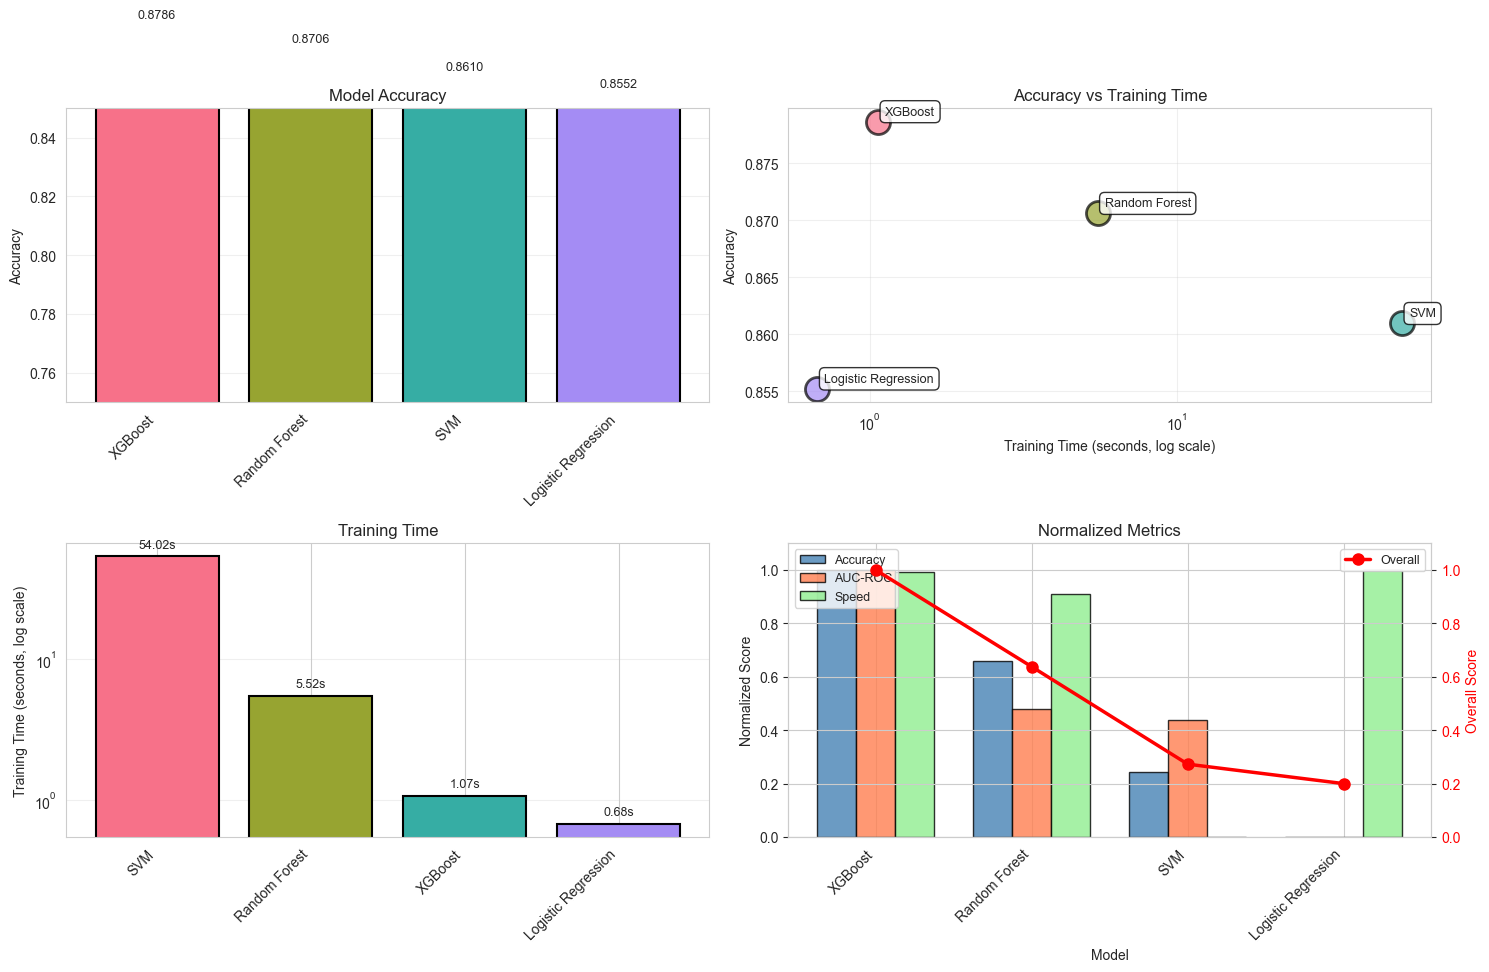


Best: XGBoost (Acc: 0.8786, AUC: 0.9452)


In [408]:
# Model comparison dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
colors = sns.color_palette("husl", len(results_df))

# Accuracy comparison
ax1 = axes[0, 0]
bars = ax1.bar(range(len(results_df)), results_df['Accuracy'], color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xticks(range(len(results_df)))
ax1.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax1.set_ylim([0.75, 0.85])
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, results_df['Accuracy']):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.002, f'{val:.4f}', ha='center', fontsize=9)

# Accuracy vs Training Time
ax2 = axes[0, 1]
for i, (_, row) in enumerate(results_df.iterrows()):
    ax2.scatter(row['Training Time (s)'], row['Accuracy'], s=300, c=[colors[i]], alpha=0.7, edgecolors='black', linewidth=2)
    ax2.annotate(row['Model'], (row['Training Time (s)'], row['Accuracy']), xytext=(5, 5), textcoords='offset points',
                fontsize=9, bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8, edgecolor='black'))
ax2.set_xlabel('Training Time (seconds, log scale)')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy vs Training Time')
ax2.set_xscale('log')
ax2.grid(True, alpha=0.3)

# Training time comparison
ax3 = axes[1, 0]
results_time_sorted = results_df.sort_values('Training Time (s)', ascending=False)
bars = ax3.bar(range(len(results_time_sorted)), results_time_sorted['Training Time (s)'], color=colors, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Training Time (seconds, log scale)')
ax3.set_title('Training Time')
ax3.set_yscale('log')
ax3.set_xticks(range(len(results_time_sorted)))
ax3.set_xticklabels(results_time_sorted['Model'], rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, results_time_sorted['Training Time (s)']):
    ax3.text(bar.get_x() + bar.get_width()/2, val * 1.15, f'{val:.2f}s', ha='center', fontsize=9)

# Normalized performance metrics
ax4 = axes[1, 1]
x = np.arange(len(results_df))
width = 0.25
ax4.bar(x - width, norm_accuracy, width, label='Accuracy', color='steelblue', alpha=0.8, edgecolor='black')
ax4.bar(x, norm_auc, width, label='AUC-ROC', color='coral', alpha=0.8, edgecolor='black')
ax4.bar(x + width, norm_speed, width, label='Speed', color='lightgreen', alpha=0.8, edgecolor='black')
ax4.set_xlabel('Model')
ax4.set_ylabel('Normalized Score')
ax4.set_title('Normalized Metrics')
ax4.set_xticks(x)
ax4.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax4.legend(loc='upper left', fontsize=9)
ax4.set_ylim([0, 1.1])
ax4.grid(axis='y', alpha=0.3)

# Overall score line
ax4_twin = ax4.twinx()
ax4_twin.plot(x, results_df['Overall Score'], 'o-', color='red', linewidth=2.5, markersize=8, label='Overall')
ax4_twin.set_ylabel('Overall Score', color='red')
ax4_twin.tick_params(axis='y', labelcolor='red')
ax4_twin.set_ylim([0, 1.1])
ax4_twin.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nBest: {results_df.iloc[0]['Model']} (Acc: {results_df.iloc[0]['Accuracy']:.4f}, AUC: {results_df.iloc[0]['AUC-ROC']:.4f})")

                 precision    recall  f1-score   support

Not Recommended       0.85      0.80      0.83      1558
    Recommended       0.89      0.92      0.91      2793

       accuracy                           0.88      4351
      macro avg       0.87      0.86      0.87      4351
   weighted avg       0.88      0.88      0.88      4351



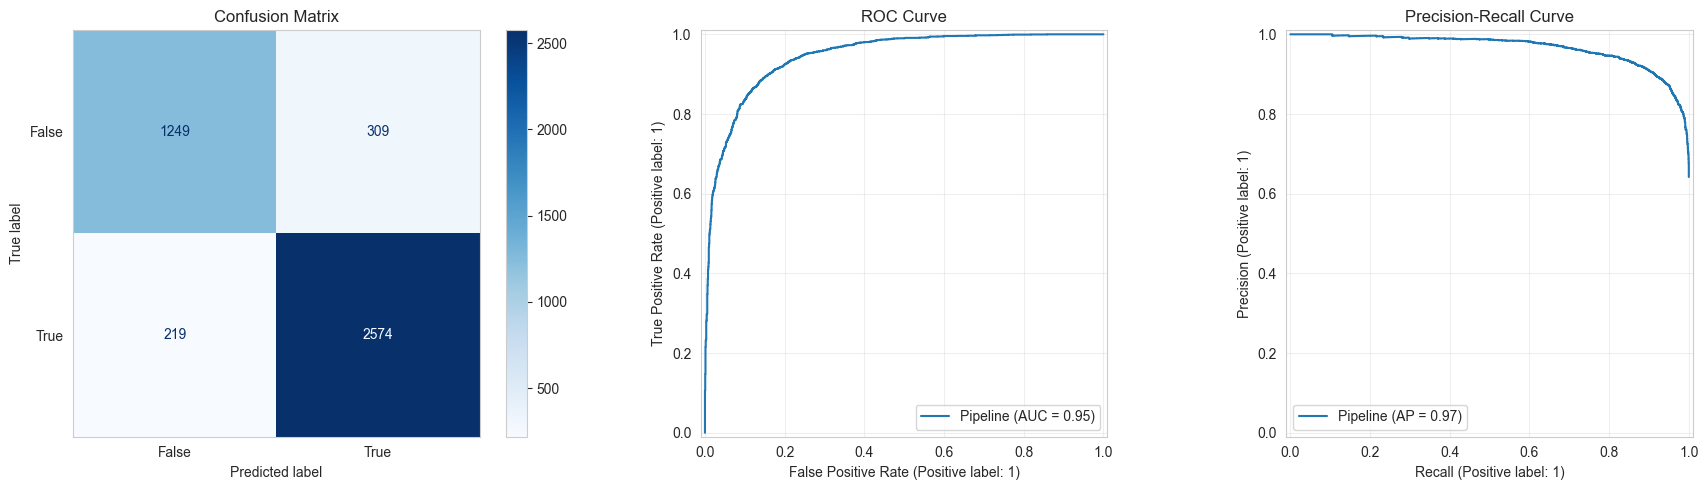

In [ ]:
y_pred = pipeline_xgb.predict(X_test)
y_proba = pipeline_xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Not Recommended', 'Recommended']))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_estimator(pipeline_xgb, X_test, y_test, ax=axes[0], cmap='Blues')
axes[0].set_title("Confusion Matrix")
axes[0].grid(False)

RocCurveDisplay.from_estimator(pipeline_xgb, X_test, y_test, ax=axes[1])
axes[1].set_title("ROC Curve")
axes[1].grid(alpha=0.3)

PrecisionRecallDisplay.from_estimator(pipeline_xgb, X_test, y_test, ax=axes[2])
axes[2].set_title("Precision-Recall Curve")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

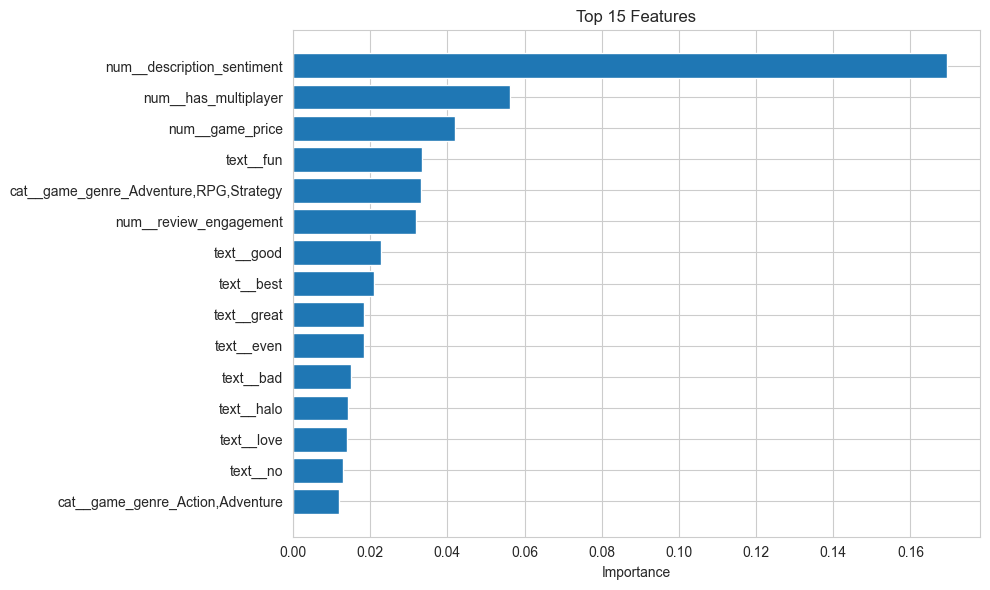

In [410]:
# Feature importance
feature_importance = pipeline_xgb.named_steps['classifier'].feature_importances_
feature_names = pipeline_xgb.named_steps['preprocessor'].get_feature_names_out()

indices = np.argsort(feature_importance)[-15:][::-1]
top_features = [(feature_names[i], feature_importance[i]) for i in indices]

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_features)), [f for _, f in top_features])
plt.yticks(range(len(top_features)), [n for n, _ in top_features])
plt.xlabel('Importance')
plt.title('Top 15 Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Making It Actionable

When the model predicts a negative review, we ask: *"What could change to turn this around?"*

### Approach

**The Prediction:** For any user and game, we predict whether they'll recommend it.

**The Counterfactuals:** When the answer is "no," we generate suggestions by testing realistic changes:
- Adjusting price
- Adding multiplayer or co-op modes  
- Improving the game description
- Adding achievements

We focus only on what game developers can actually control—not player behavior or review sentiment.

In [ ]:
def predict_with_counterfactuals(model, user_features, total_CFs=3):
    """
    Predict recommendation outcome and generate counterfactual suggestions.
    
    For negative predictions, tests actionable changes to game features
    (price, multiplayer, achievements, etc.) to identify improvements that
    could flip the prediction or increase recommendation probability.
    """
    prediction = model.predict(user_features)[0]
    prob = model.predict_proba(user_features)[0][1]
    
    counterfactuals = []
    
    if not prediction:
        # Test different actionable changes to game features
        test_features = user_features.copy()
        original_prob = prob
        
        suggestions = []
        
        # Test 1: Reduce price significantly
        if user_features['game_price'].values[0] > 20:
            test_features = user_features.copy()
            new_price = 19.99
            test_features['game_price'] = new_price
            new_prob = model.predict_proba(test_features)[0][1]
            new_pred = model.predict(test_features)[0]
            
            suggestions.append({
                'feature': 'game_price',
                'original': user_features['game_price'].values[0],
                'suggested': new_price,
                'description': f"Reduce price to ${new_price}",
                'prob_increase': new_prob - original_prob,
                'flips_prediction': new_pred
            })
        
        # Test 2: Add multiplayer
        if user_features['has_multiplayer'].values[0] == 0:
            test_features = user_features.copy()
            test_features['has_multiplayer'] = 1
            new_prob = model.predict_proba(test_features)[0][1]
            new_pred = model.predict(test_features)[0]
            
            suggestions.append({
                'feature': 'has_multiplayer',
                'original': 0,
                'suggested': 1,
                'description': "Add multiplayer mode",
                'prob_increase': new_prob - original_prob,
                'flips_prediction': new_pred
            })
        
        # Test 3: Add co-op
        if user_features['has_coop'].values[0] == 0:
            test_features = user_features.copy()
            test_features['has_coop'] = 1
            new_prob = model.predict_proba(test_features)[0][1]
            new_pred = model.predict(test_features)[0]
            
            suggestions.append({
                'feature': 'has_coop',
                'original': 0,
                'suggested': 1,
                'description': "Add co-op mode",
                'prob_increase': new_prob - original_prob,
                'flips_prediction': new_pred
            })
        
        # Test 4: Add achievements
        if user_features['has_achievements'].values[0] == 0:
            test_features = user_features.copy()
            test_features['has_achievements'] = 1
            new_prob = model.predict_proba(test_features)[0][1]
            new_pred = model.predict(test_features)[0]
            
            suggestions.append({
                'feature': 'has_achievements',
                'original': 0,
                'suggested': 1,
                'description': "Add achievements",
                'prob_increase': new_prob - original_prob,
                'flips_prediction': new_pred
            })
        
        # Test 5: Improve description sentiment
        if user_features['description_sentiment'].values[0] < 0.5:
            test_features = user_features.copy()
            test_features['description_sentiment'] = 0.7
            new_prob = model.predict_proba(test_features)[0][1]
            new_pred = model.predict(test_features)[0]
            
            suggestions.append({
                'feature': 'description_sentiment',
                'original': user_features['description_sentiment'].values[0],
                'suggested': 0.7,
                'description': "Improve game description (more positive)",
                'prob_increase': new_prob - original_prob,
                'flips_prediction': new_pred
            })
        
        # Test 6: Combined changes (price + multiplayer)
        if user_features['game_price'].values[0] > 20 and user_features['has_multiplayer'].values[0] == 0:
            test_features = user_features.copy()
            test_features['game_price'] = 19.99
            test_features['has_multiplayer'] = 1
            new_prob = model.predict_proba(test_features)[0][1]
            new_pred = model.predict(test_features)[0]
            
            suggestions.append({
                'feature': 'combined',
                'original': None,
                'suggested': None,
                'description': "Reduce price to $19.99 AND add multiplayer",
                'prob_increase': new_prob - original_prob,
                'flips_prediction': new_pred
            })
        
        # Sort by impact and return top counterfactuals
        suggestions.sort(key=lambda x: x['prob_increase'], reverse=True)
        counterfactuals = suggestions[:total_CFs]
    
    return bool(prediction), float(prob), counterfactuals

In [ ]:
test_cases = [
    # Case 1: Positive example (baseline)
    pd.DataFrame({
        'review_text': ["Fantastic game! Hours of fun with great features."],
        'log_playtime_at_review': [np.log1p(55.0)],
        'playtime_ratio': [0.87],
        'user_experience_level': [1],
        'review_length': [95],
        'review_engagement': [40],
        'game_price': [39.99],
        'game_required_age': [12],
        'game_description_length': [48],
        'description_sentiment': [0.42],
        'game_genre': ['Action'],
        'has_multiplayer': [1],
        'has_coop': [1],
        'has_achievements': [1],
    }),

    # Case 2: Borderline positive - has some features, decent playtime
    pd.DataFrame({
        'review_text': ["Decent but lacks content and features."],
        'log_playtime_at_review': [np.log1p(45.0)],
        'playtime_ratio': [0.88],
        'user_experience_level': [1],
        'review_length': [65],
        'review_engagement': [15],
        'game_price': [49.99],
        'game_required_age': [15],
        'game_description_length': [30],
        'description_sentiment': [0.22],
        'game_genre': ['Action'],
        'has_multiplayer': [1],
        'has_coop': [0],
        'has_achievements': [1],
    }),

    # Case 3: Strong negative - low playtime, shows improvements but doesn't flip
    pd.DataFrame({
        'review_text': ["Not worth it, disappointing overall."],
        'log_playtime_at_review': [np.log1p(4.2)],
        'playtime_ratio': [0.83],
        'user_experience_level': [1],
        'review_length': [60],
        'review_engagement': [9],
        'game_price': [64.99],
        'game_required_age': [16],
        'game_description_length': [22],
        'description_sentiment': [0.12],
        'game_genre': ['Action'],
        'has_multiplayer': [0],
        'has_coop': [0],
        'has_achievements': [0],
    })
]

In [422]:
for i, case in enumerate(test_cases, 1):
    pred, prob, counterfactuals = predict_with_counterfactuals(pipeline_xgb, case)
    
    print(f"Case {i}: {case['review_text'].values[0]}")
    print(f"Prediction: {'RECOMMENDED' if pred else 'NOT RECOMMENDED'} ({prob:.1%})\n")
    
    if not pred and counterfactuals:
        print("Counterfactual Suggestions:")
        for j, cf in enumerate(counterfactuals, 1):
            impact = "✓ Flips to RECOMMENDED" if cf['flips_prediction'] else f"+{cf['prob_increase']*100:.1f}% probability"
            print(f"  {j}. {cf['description']} → {impact}")
        print()
    elif not pred:
        print("No actionable changes found.\n")
    
    print("-" * 80 + "\n")

Case 1: Fantastic game! Hours of fun with great features.
Prediction: RECOMMENDED (97.5%)

--------------------------------------------------------------------------------

Case 2: Decent but lacks content and features.
Prediction: NOT RECOMMENDED (14.7%)

Counterfactual Suggestions:
  1. Improve game description (more positive) → ✓ Flips to RECOMMENDED
  2. Reduce price to $19.99 AND add multiplayer → +10.5% probability
  3. Reduce price to $19.99 → +5.4% probability

--------------------------------------------------------------------------------

Case 3: Not worth it, disappointing overall.
Prediction: NOT RECOMMENDED (0.5%)

Counterfactual Suggestions:
  1. Improve game description (more positive) → +3.9% probability
  2. Reduce price to $19.99 AND add multiplayer → +2.8% probability
  3. Reduce price to $19.99 → +1.9% probability

--------------------------------------------------------------------------------



## What We Learned

This project demonstrates how AI can be both accurate and interpretable:

**The Model:**  
XGBoost achieved 88% accuracy by learning patterns from over 21,000 reviews across 10 games.

**The Insights:**  
Playtime, review sentiment, and game price emerged as the strongest signals.

**The Value:**  
When predicting negative reviews, our counterfactual system suggests actionable changes—like adding multiplayer features or adjusting pricing—giving developers clear paths to improvement.